In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from matplotlib.lines import Line2D

In [6]:
# plot parameters
plt.style.use('my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)


In [7]:
cmap = colormaps['Paired']     
mycolors = cmap.colors[::2]
cluster_sizes = [5,7,8,6]

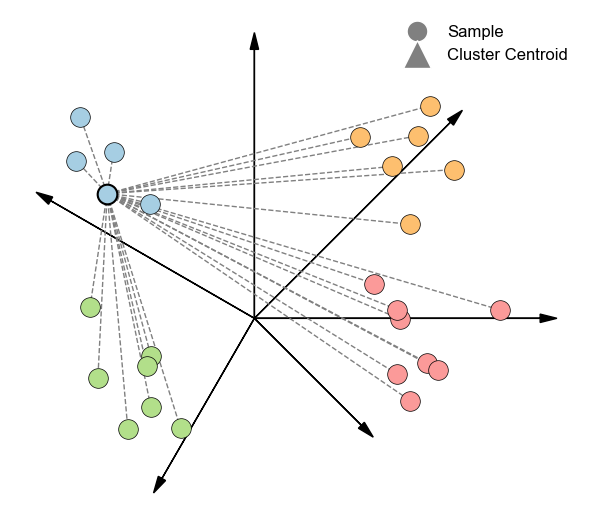

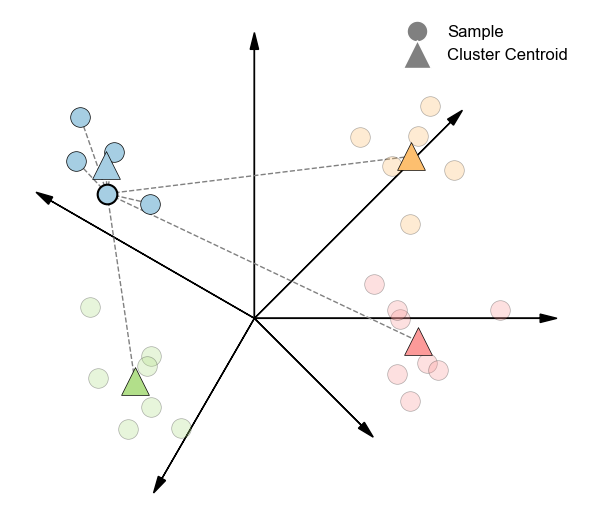

In [ ]:
for mode in ['prev', 'now']:    
    rs = [1.8,1.75,1.7,1.5,1.2,1.]
    angles = [0.0,np.pi/4, np.pi/2, np.pi/6*5, -np.pi/3*2,-np.pi/4,]

    zorder_dict = {'samples': 2, 'centers': 4, 'lines': 1, 'axes': 0, 'specific_sample':3}

    cluster_centers = [(-1, 0.8), (-0.5, -0.3), (1., -0), (1., 1)]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_aspect('equal')
    # plot axis
    for r, angle in zip(rs, angles):
        dx = r * np.cos(angle)
        dy = r * np.sin(angle)
        ax.arrow(0, 0, dx, dy,
                head_width=0.05, head_length=0.1,  
                fc='black', ec='black', length_includes_head=True, linewidth=1,alpha=1, zorder=zorder_dict['axes'])

    # plot dots
    np.random.seed(42)
    samplelocs = []
    for i,center in enumerate(cluster_centers):
        x_center, y_center = center
        x = x_center + 0.25 * np.random.randn(cluster_sizes[i])
        y = y_center + 0.25 * np.random.randn(cluster_sizes[i])
        samplelocs.append((x, y))


    # choose the first point in the first cluster
    x0, y0 = samplelocs[0][0][0], samplelocs[0][1][0]
    ax.scatter([x0], [y0], s=200, marker='o', color=mycolors[0],zorder=zorder_dict['specific_sample'],linewidths=1.5, edgecolors='black')   
    if mode == 'prev':
        # plot all points with same alpha
        for i, samples in enumerate(samplelocs):
            ax.scatter(samples[0], samples[1], s=200, marker='o', color=mycolors[i],zorder=zorder_dict['samples'],
                    alpha=1,linewidths=0.5, edgecolors='black')
        # connect one point with everyone else
        for samples in samplelocs:
            for x, y in zip(samples[0], samples[1]):
                ax.plot([x0, x], [y0, y], '--',color='grey', alpha=1, linewidth=1, zorder = zorder_dict['lines'])
    elif mode == 'now':
        # plot all points, but points in the first cluster with alpha=1, others with alpha=0.5
        ax.scatter(samplelocs[0][0], samplelocs[0][1], s=200, marker='o', color=mycolors[0],zorder=zorder_dict['samples'],
                alpha=1,linewidths=0.5, edgecolors='black') 
        for i, samples in enumerate(samplelocs[1:]):
            ax.scatter(samples[0], samples[1], s=200, marker='o', color=mycolors[i+1],zorder=zorder_dict['samples'],
                    alpha=0.3,linewidths=0.5, edgecolors='black')
        # or: compute actual cluster centers for each cluster
        actual_centers = []
        for i,samples in enumerate(samplelocs):
            x_mean = np.mean(samples[0])
            y_mean = np.mean(samples[1])
            actual_centers.append((x_mean, y_mean))
            ax.scatter(x_mean, y_mean, s=400, marker='^',color = mycolors[i],linewidths=0.5, edgecolors='black',zorder=zorder_dict['centers'])
        # connect x0 y0 to every point in its cluster, and to  cluster centroids including itself
        for x, y in zip(samplelocs[0][0], samplelocs[0][1]):
            ax.plot([x0, x], [y0, y], '--',color='grey', alpha=1, linewidth=1, zorder = zorder_dict['lines'])
        for x_mean, y_mean in actual_centers:
            ax.plot([x0, x_mean], [y0, y_mean], '--',color='grey', alpha=1, linewidth=1, zorder = zorder_dict['lines'])

    # add legend: shape ^ is cluster center, o is sample, add manually

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=15, label='Sample'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='grey', markersize=20, label='Cluster Centroid'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=False)

    ax.axis('off')
    plt.tight_layout()
    # plt.savefig('%s_featspace.svg'%mode,format='svg',transparent=True)

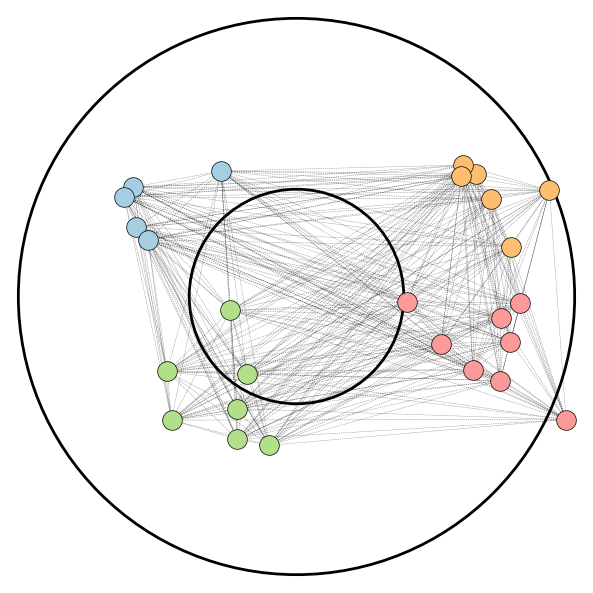

In [ ]:
# plot embedding: circles
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

cluster_centers = [(-1, 0.5), (-0.5, -0.6), (1., -0.3), (1., 0.7)]

radii = np.tanh(np.array([0.5,1.5])/2)/np.tanh(1)*2
for r in radii:
    circle = plt.Circle((0, 0), r, color='black', fill=False, linewidth=2.0,zorder = zorder_dict['axes'])
    ax.add_artist(circle)

# plot samples
np.random.seed(18)

samplelocs = []
for i,center in enumerate(cluster_centers):
    x_center, y_center = center
    x = x_center + 0.25 * np.random.randn(cluster_sizes[i])
    y = y_center + 0.25 * np.random.randn(cluster_sizes[i])
    ax.scatter(x, y, s=200, color=mycolors[i],zorder = zorder_dict['samples'], linewidths=0.5, edgecolors='black')
    samplelocs.append((x, y))

# all to all connections
alllocs = np.concatenate(samplelocs, axis=1)
for i in range(alllocs.shape[1]):
    for j in range(alllocs.shape[1]):
        if i < j:
            ax.plot([alllocs[0, i], alllocs[0, j]], [alllocs[1, i], alllocs[1, j]],'--',color='black', alpha=0.5, linewidth=0.3,zorder=1)

plt.xlim(-max(radii)-0.05, max(radii)+0.05)
plt.ylim(-max(radii)-0.05, max(radii)+0.05)

ax.axis('off')
plt.tight_layout()

# plt.savefig('prev_hyp.svg',format='svg',transparent=True)



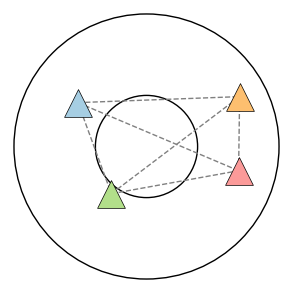

In [ ]:
# centroids
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')

radii = np.tanh(np.array([0.5,1.5])/2)/np.tanh(1)*2
for r in radii:
    circle = plt.Circle((0, 0), r, color='black', fill=False, linewidth=1.0,zorder = zorder_dict['axes'])
    ax.add_artist(circle)
actual_centers = []
for i, samples in enumerate(samplelocs):
    x, y = samples
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    ax.scatter(x_mean, y_mean, s=400, marker='^', color=mycolors[i],zorder = zorder_dict['centers'],
               linewidths=0.5, edgecolors='black')
    actual_centers.append((x_mean, y_mean))
# connect centroids to each other
for i, (x_mean, y_mean) in enumerate(actual_centers):
    for j, (x_mean2, y_mean2) in enumerate(actual_centers):
        if i < j:
            ax.plot([x_mean, x_mean2], [y_mean, y_mean2], '--',color='grey', alpha=1.0, linewidth=1.0)

plt.xlim(-max(radii)-0.05, max(radii)+0.05)
plt.ylim(-max(radii)-0.05, max(radii)+0.05)

ax.axis('off')
plt.tight_layout()

# plt.savefig('now_cls_hyp.svg',format='svg',transparent=True)



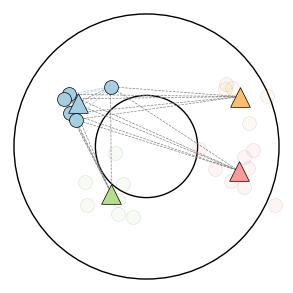

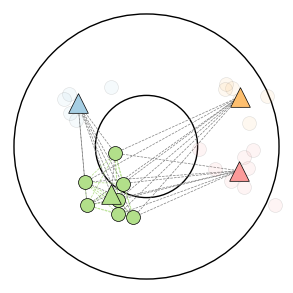

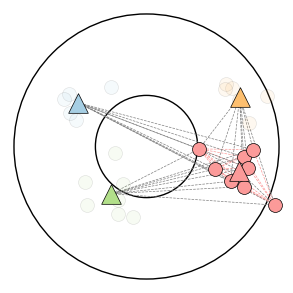

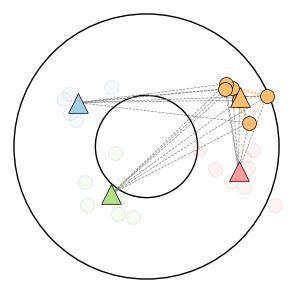

In [ ]:
for popind in [0,1,2,3]: 
# in parallel: inter-cluster distances + distances to centroids
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect('equal')

    radii = np.tanh(np.array([0.5,1.5])/2)/np.tanh(1)*2
    for r in radii:
        circle = plt.Circle((0, 0), r, color='black', fill=False, linewidth=1.0,zorder = zorder_dict['axes'])
        ax.add_artist(circle)

    # plot sample in popind-th cluster with alpha=1, others with alpha=0.5
    for i, samples in enumerate(samplelocs):
        if i == popind:
            ax.scatter(samples[0], samples[1], s=100, marker='o', color=mycolors[i],zorder=zorder_dict['samples'],
                    alpha=1,linewidths=0.5, edgecolors='black') 
        else:
            ax.scatter(samples[0], samples[1], s=100, marker='o', color=mycolors[i],zorder=zorder_dict['samples'],
                    alpha=0.1,linewidths=0.5, edgecolors='black')
    # plot cluster centroids
    for i, (x_mean, y_mean) in enumerate(actual_centers):
        ax.scatter(x_mean, y_mean, s=200, marker='^', color=mycolors[i],zorder = zorder_dict['centers'],
                linewidths=0.5, edgecolors='black')

    # connect every point in popind-th cluster to every other point in the same cluster
    for i,(x, y) in enumerate(zip(samplelocs[popind][0], samplelocs[popind][1])):
        for j,(x2, y2) in enumerate(zip(samplelocs[popind][0], samplelocs[popind][1])):
            if i < j:
                ax.plot([x, x2], [y, y2], '--',color=mycolors[popind], alpha=1, linewidth=0.5, zorder = zorder_dict['lines'])
    # connect every point in popind-th cluster to every cluster centroid
    for x_mean, y_mean in actual_centers:
        for x, y in zip(samplelocs[popind][0], samplelocs[popind][1]):
            ax.plot([x, x_mean], [y, y_mean], '--',color='grey', alpha=1.0, linewidth=0.5, zorder = zorder_dict['lines'])
    plt.xlim(-max(radii)-0.05, max(radii)+0.05)
    plt.ylim(-max(radii)-0.05, max(radii)+0.05)

    ax.axis('off')
    plt.tight_layout()

    # plt.savefig('now_pop_%i_hyp.svg'%popind,format='svg',transparent=True)
